In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries OK")

Libraries OK


In [6]:
import os, glob

files = glob.glob("../data/raw/*.csv") or glob.glob("data/raw/*.csv")
print(files)

df = pd.read_csv(files[0])
print(df.shape)

['../data/raw\\factory_sensor_data.csv.csv']
(500000, 17)


In [7]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Unique Machine_IDs:", df["Machine_ID"].nunique())

Missing values:
 Machine_ID                    0
Machine_Type                  0
Installation_Year             0
Operational_Hours             0
Temperature_C                 0
Vibration_mms                 0
Sound_dB                      0
Oil_Level_pct                 0
Coolant_Level_pct             0
Power_Consumption_kW          0
Last_Maintenance_Days_Ago     0
Maintenance_History_Count     0
Failure_History_Count         0
AI_Supervision                0
Error_Codes_Last_30_Days      0
Remaining_Useful_Life_days    0
Failure_Within_7_Days         0
dtype: int64

Duplicate rows: 0
Unique Machine_IDs: 500000


In [8]:
print("Machine types:", df["Machine_Type"].nunique())
print(df["Machine_Type"].value_counts().head(10))

Machine types: 33
Machine_Type
AGV                   15409
Shuttle_System        15372
Crane                 15362
Labeler               15347
CNC_Lathe             15290
Industrial_Chiller    15270
CMM                   15265
Pump                  15228
Vacuum_Packer         15219
Injection_Molder      15216
Name: count, dtype: int64


In [9]:
print(df["Failure_Within_7_Days"].value_counts())
print()
print(df["Failure_Within_7_Days"].value_counts(normalize=True).round(4))

Failure_Within_7_Days
False    469968
True      30032
Name: count, dtype: int64

Failure_Within_7_Days
False    0.9399
True     0.0601
Name: proportion, dtype: float64


In [10]:
print("Negative vibration:", (df["Vibration_mms"] < 0).sum())
print("Negative power:", (df["Power_Consumption_kW"] < 0).sum())
print("Negative temperature:", (df["Temperature_C"] < 0).sum())
print("Installation year > 2026:", (df["Installation_Year"] > 2026).sum())

Negative vibration: 11467
Negative power: 15175
Negative temperature: 18
Installation year > 2026: 170041


In [11]:
print("RUL <= 7 aur Failure=True:", ((df["Remaining_Useful_Life_days"] <= 7) & (df["Failure_Within_7_Days"])).sum())
print("Failure=True total:", df["Failure_Within_7_Days"].sum())
print("Corr (Operational_Hours, RUL):", round(df["Operational_Hours"].corr(df["Remaining_Useful_Life_days"]), 3))

RUL <= 7 aur Failure=True: 30032
Failure=True total: 30032
Corr (Operational_Hours, RUL): -0.985


In [12]:
df_clean = df.copy()
print(df_clean.columns.tolist())
print("Rows before cleaning:", len(df_clean))

['Machine_ID', 'Machine_Type', 'Installation_Year', 'Operational_Hours', 'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct', 'Coolant_Level_pct', 'Power_Consumption_kW', 'Last_Maintenance_Days_Ago', 'Maintenance_History_Count', 'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days', 'Remaining_Useful_Life_days', 'Failure_Within_7_Days']
Rows before cleaning: 500000


In [13]:
neg_cols = ["Vibration_mms", "Power_Consumption_kW", "Temperature_C"]

for col in neg_cols:
    n_bad = (df_clean[col] < 0).sum()
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: {n_bad} negative values replaced with median {median_val:.2f}")

Vibration_mms: 11467 negative values replaced with median 10.14
Power_Consumption_kW: 15175 negative values replaced with median 153.03
Temperature_C: 18 negative values replaced with median 60.00


In [14]:
CURRENT_YEAR = 2026

future = df_clean["Installation_Year"] > CURRENT_YEAR
print("Future years found:", future.sum())

valid_median = df_clean.loc[~future, "Installation_Year"].median()
df_clean.loc[future, "Installation_Year"] = valid_median

df_clean["Machine_Age"] = CURRENT_YEAR - df_clean["Installation_Year"]
df_clean = df_clean.drop(columns=["Installation_Year"])
print("Machine_Age range:", df_clean["Machine_Age"].min(), "to", df_clean["Machine_Age"].max())

Future years found: 170041
Machine_Age range: 0 to 26


In [15]:
bool_cols = df_clean.select_dtypes(include="bool").columns.tolist()
print("Boolean columns:", bool_cols)

for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

Boolean columns: ['AI_Supervision', 'Failure_Within_7_Days']


In [16]:
df_clean = df_clean.drop(columns=["Machine_ID"])
print(df_clean.shape)

(500000, 16)


In [17]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Negative vibration:", (df_clean["Vibration_mms"] < 0).sum())
print("Negative power:", (df_clean["Power_Consumption_kW"] < 0).sum())
print("Negative temperature:", (df_clean["Temperature_C"] < 0).sum())
print("Min Machine_Age:", df_clean["Machine_Age"].min())
print()
print("Failure rate before:", round(df["Failure_Within_7_Days"].mean(), 4))
print("Failure rate after :", round(df_clean["Failure_Within_7_Days"].mean(), 4))

Missing values: 0
Negative vibration: 0
Negative power: 0
Negative temperature: 0
Min Machine_Age: 0

Failure rate before: 0.0601
Failure rate after : 0.0601


In [18]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/cleaned_data.csv", index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (500000, 16)


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_data.csv")
sns.set_theme(style="whitegrid")
print(df.shape)

(500000, 16)


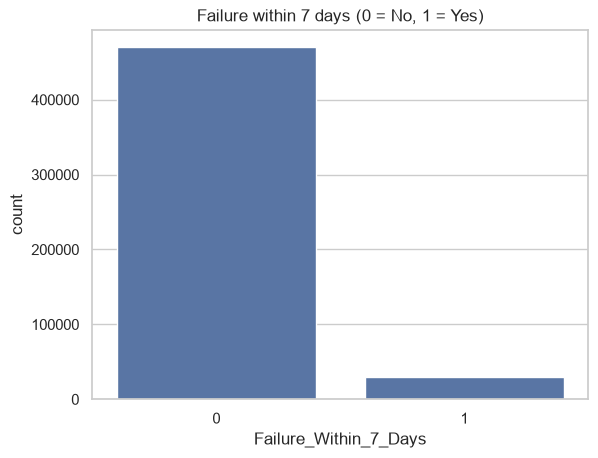

Failure_Within_7_Days
0    0.9399
1    0.0601
Name: proportion, dtype: float64


In [20]:
ax = sns.countplot(x="Failure_Within_7_Days", data=df)
ax.set_title("Failure within 7 days (0 = No, 1 = Yes)")
plt.show()

print(df["Failure_Within_7_Days"].value_counts(normalize=True).round(4))

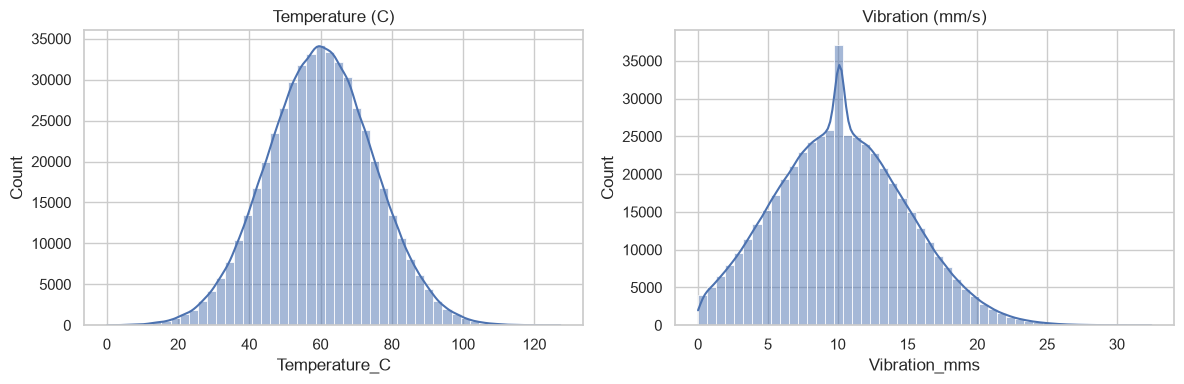

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Temperature_C"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Temperature (C)")
sns.histplot(df["Vibration_mms"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Vibration (mm/s)")
plt.tight_layout()
plt.show()

In [22]:
sensor_cols = ["Temperature_C", "Vibration_mms", "Sound_dB", "Oil_Level_pct",
               "Coolant_Level_pct", "Power_Consumption_kW"]
df.groupby("Failure_Within_7_Days")[sensor_cols].mean().round(2).T

Failure_Within_7_Days,0,1
Temperature_C,59.90,61.55
Vibration_mms,10.23,10.92
Sound_dB,75.01,74.95
Oil_Level_pct,69.46,69.39
Coolant_Level_pct,64.13,63.92
Power_Consumption_kW,155.51,155.47


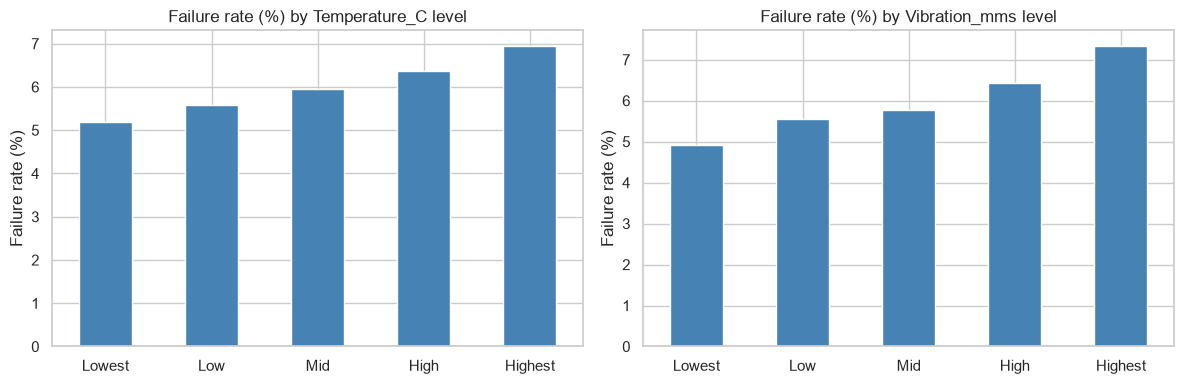

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["Temperature_C", "Vibration_mms"]):
    bins = pd.qcut(df[col], 5, labels=["Lowest", "Low", "Mid", "High", "Highest"])
    rate = df.groupby(bins, observed=True)["Failure_Within_7_Days"].mean() * 100
    rate.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Failure rate (%) by {col} level")
    ax.set_ylabel("Failure rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

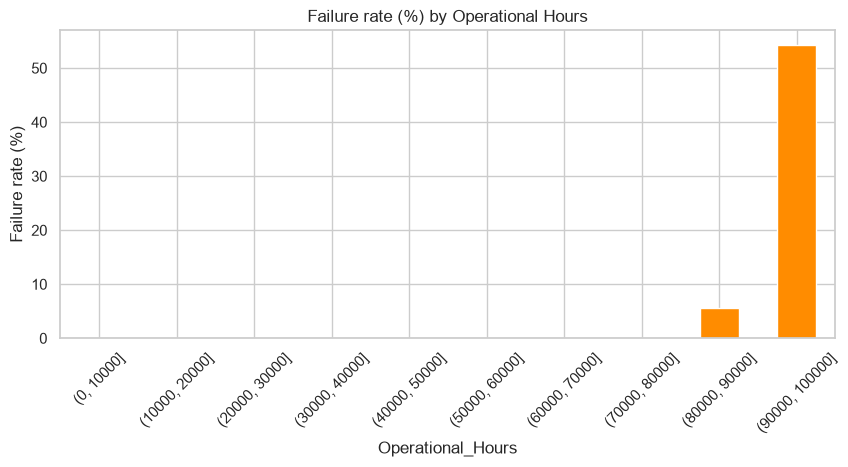

Operational_Hours
(0, 10000]          0.0
(10000, 20000]      0.0
(20000, 30000]      0.0
(30000, 40000]      0.0
(40000, 50000]      0.0
(50000, 60000]      0.0
(60000, 70000]      0.0
(70000, 80000]      0.0
(80000, 90000]      5.6
(90000, 100000]    54.3
Name: Failure_Within_7_Days, dtype: float64


In [24]:
bins = pd.cut(df["Operational_Hours"], bins=range(0, 110000, 10000))
rate = df.groupby(bins, observed=True)["Failure_Within_7_Days"].mean() * 100
rate.plot(kind="bar", figsize=(10, 4), color="darkorange")
plt.title("Failure rate (%) by Operational Hours")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=45)
plt.show()
print(rate.round(1))

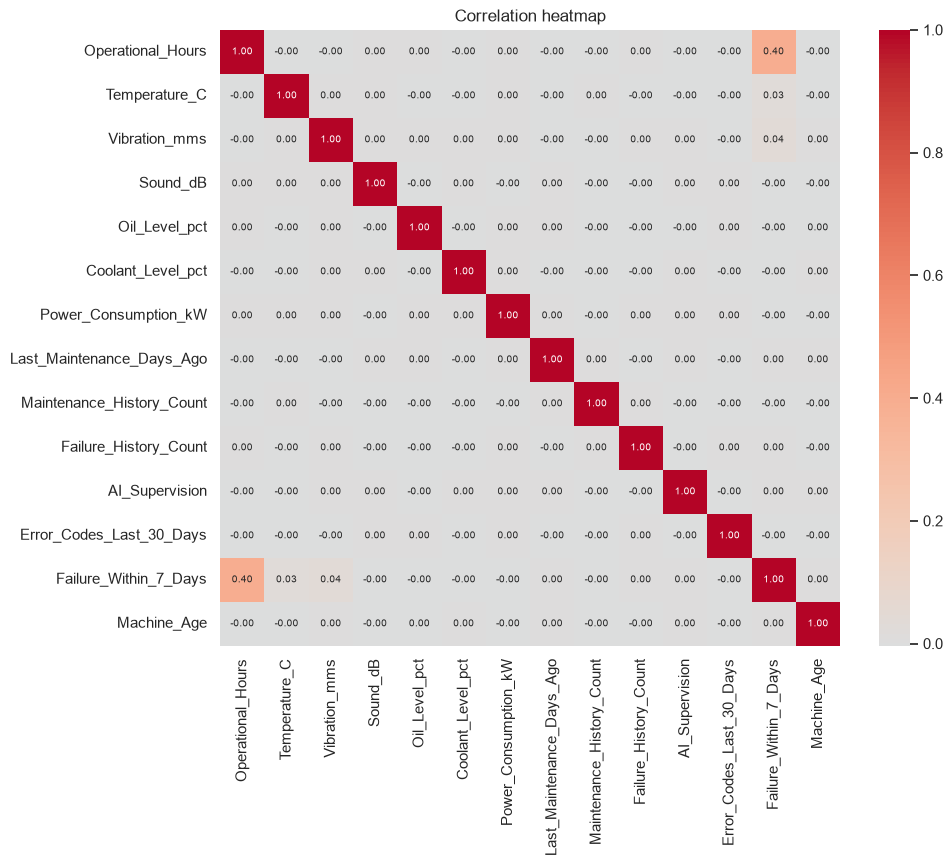

Operational_Hours            0.397
Vibration_mms                0.035
Temperature_C                0.026
Failure_History_Count        0.002
Machine_Age                  0.001
AI_Supervision               0.000
Last_Maintenance_Days_Ago    0.000
Power_Consumption_kW        -0.000
Maintenance_History_Count   -0.000
Oil_Level_pct               -0.001
Error_Codes_Last_30_Days    -0.001
Sound_dB                    -0.001
Coolant_Level_pct           -0.002
Name: Failure_Within_7_Days, dtype: float64


In [25]:
num_cols = df.select_dtypes(include="number").columns.drop("Remaining_Useful_Life_days")
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation heatmap")
plt.show()

print(df[num_cols].corr()["Failure_Within_7_Days"].drop("Failure_Within_7_Days").sort_values(ascending=False).round(3))

In [26]:
print("Corr (Operational_Hours, Temperature):", round(df["Operational_Hours"].corr(df["Temperature_C"]), 3))
print("Corr (Operational_Hours, Vibration):", round(df["Operational_Hours"].corr(df["Vibration_mms"]), 3))

old = df[df["Operational_Hours"] >= 80000]
print("\nMachines with >= 80,000 hours:", len(old))
print("Failure rate among them:", round(old["Failure_Within_7_Days"].mean(), 3))
print("Failure rate below 80,000 hours:",
      round(df[df["Operational_Hours"] < 80000]["Failure_Within_7_Days"].mean(), 4))

print("\nCorrelation with failure among old machines:")
print(old[["Temperature_C", "Vibration_mms", "Failure_Within_7_Days"]].corr()["Failure_Within_7_Days"].round(3))

Corr (Operational_Hours, Temperature): -0.001
Corr (Operational_Hours, Vibration): -0.001

Machines with >= 80,000 hours: 99976
Failure rate among them: 0.3
Failure rate below 80,000 hours: 0.0001

Correlation with failure among old machines:
Temperature_C            0.069
Vibration_mms            0.092
Failure_Within_7_Days    1.000
Name: Failure_Within_7_Days, dtype: float64


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/cleaned_data.csv")

target = "Failure_Within_7_Days"
leak_cols = ["Remaining_Useful_Life_days"]   # leakage, model ko nahi dena

X = df.drop(columns=[target] + leak_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X:", X.shape, "| y:", y.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train failures:", y_train.sum(), f"({y_train.mean():.2%})")
print("Test failures :", y_test.sum(), f"({y_test.mean():.2%})")
print("Overlap train/test:", len(set(X_train.index) & set(X_test.index)))
print("RUL in features?", "Remaining_Useful_Life_days" in X.columns)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)
print("Saved train/test files")

X: (500000, 14) | y: (500000,)
X_train: (400000, 14) | X_test: (100000, 14)
Train failures: 24026 (6.01%)
Test failures : 6006 (6.01%)
Overlap train/test: 0
RUL in features? False
Saved train/test files


In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
print(X_train.shape, y_train.shape)

(400000, 14) (400000,)


In [2]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(X_fit.shape, X_val.shape)
print("Failures in fit:", y_fit.sum(), "| in val:", y_val.sum())

(320000, 14) (80000, 14)
Failures in fit: 19221 | in val: 4805


In [3]:
cat_cols = ["Machine_Type"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

def make_preprocessor(scale=False):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler() if scale else "passthrough", num_cols),
    ])

print(cat_cols, len(num_cols))

['Machine_Type'] 13


In [4]:
results = {}

def evaluate(name, model):
    start = time.time()
    model.fit(X_fit, y_fit)
    proba = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    results[name] = {
        "Accuracy":  accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall":    recall_score(y_val, pred),
        "F1":        f1_score(y_val, pred),
        "ROC-AUC":   roc_auc_score(y_val, proba),
        "PR-AUC":    average_precision_score(y_val, proba),
        "Time (s)":  time.time() - start,
    }
    print(name, "done in", round(results[name]["Time (s)"], 1), "s")
    return model

dummy = evaluate("Dummy", Pipeline([
    ("prep", make_preprocessor()),
    ("model", DummyClassifier(strategy="prior")),
]))
print(pd.DataFrame(results).T.round(3))

Dummy done in 0.9 s
       Accuracy  Precision  Recall   F1  ROC-AUC  PR-AUC  Time (s)
Dummy      0.94        0.0     0.0  0.0      0.5    0.06     0.873


In [5]:
log_reg = evaluate("Logistic Regression", Pipeline([
    ("prep", make_preprocessor(scale=True)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
]))

Logistic Regression done in 3.1 s


In [6]:
rf = evaluate("Random Forest", Pipeline([
    ("prep", make_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=100, min_samples_leaf=5,
        class_weight="balanced", n_jobs=-1, random_state=42)),
]))

Random Forest done in 34.4 s


In [7]:
hgb = evaluate("Gradient Boosting", Pipeline([
    ("prep", make_preprocessor()),
    ("model", HistGradientBoostingClassifier(random_state=42)),
]))

Gradient Boosting done in 5.1 s


In [8]:
comparison = pd.DataFrame(results).T.round(3)
comparison.sort_values("PR-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Time (s)
Logistic Regression,0.927,0.452,0.974,0.617,0.983,0.747,3.101
Gradient Boosting,0.964,0.713,0.661,0.686,0.982,0.745,5.056
Random Forest,0.936,0.484,0.957,0.643,0.981,0.701,34.445
Dummy,0.940,0.000,0.000,0.000,0.500,0.060,0.873


In [9]:
print(list(results.keys()))

['Dummy', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

thresholds = np.arange(0.05, 0.95, 0.01)
val_proba, rows = {}, []

for name, mdl in [("Logistic Regression", log_reg),
                  ("Random Forest", rf),
                  ("Gradient Boosting", hgb)]:
    p = mdl.predict_proba(X_val)[:, 1]
    val_proba[name] = p
    f1s = [f1_score(y_val, p >= t) for t in thresholds]
    t = thresholds[int(np.argmax(f1s))]
    rows.append({"Model": name, "Best threshold": round(t, 2),
                 "F1": f1_score(y_val, p >= t),
                 "Precision": precision_score(y_val, p >= t),
                 "Recall": recall_score(y_val, p >= t)})

pd.DataFrame(rows).round(3)

,Model,Best threshold,F1,Precision,Recall
0,Logistic Regression,0.88,0.708,0.626,0.814
1,Random Forest,0.80,0.707,0.632,0.801
2,Gradient Boosting,0.35,0.706,0.633,0.798


In [11]:
p = val_proba["Gradient Boosting"]
table = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    table.append({"Threshold": t,
                  "Precision": precision_score(y_val, p >= t),
                  "Recall": recall_score(y_val, p >= t),
                  "F1": f1_score(y_val, p >= t)})
print(pd.DataFrame(table).round(3))

best_thr = float(thresholds[int(np.argmax([f1_score(y_val, p >= t) for t in thresholds]))])
print("\nChosen threshold:", round(best_thr, 2))

   Threshold  Precision  Recall     F1
0        0.2      0.550   0.900  0.683
1        0.3      0.608   0.833  0.703
2        0.4      0.659   0.755  0.704
3        0.5      0.713   0.661  0.686
4        0.6      0.758   0.547  0.635

Chosen threshold: 0.35


In [12]:
final_model = Pipeline([
    ("prep", make_preprocessor()),
    ("model", HistGradientBoostingClassifier(random_state=42)),
])
final_model.fit(X_train, y_train)
print("Final model trained on", X_train.shape[0], "rows")

Final model trained on 400000 rows


In [13]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

test_proba = final_model.predict_proba(X_test)[:, 1]

rows = []
for label, thr in [("Default 0.5", 0.5), (f"Tuned {best_thr:.2f}", best_thr)]:
    pred = test_proba >= thr
    rows.append({"Threshold": label,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred)})

print(pd.DataFrame(rows).round(3))
print("\nROC-AUC:", round(roc_auc_score(y_test, test_proba), 3))
print("PR-AUC :", round(average_precision_score(y_test, test_proba), 3))

     Threshold  Accuracy  Precision  Recall     F1
0  Default 0.5     0.964      0.716   0.665  0.689
1   Tuned 0.35     0.961      0.640   0.807  0.714

ROC-AUC: 0.983
PR-AUC : 0.748


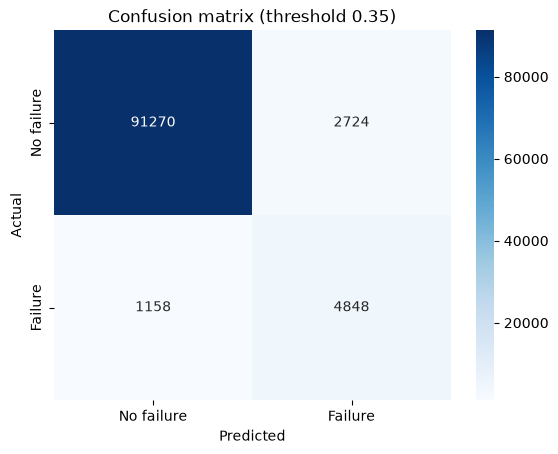

[[91270  2724]
 [ 1158  4848]]


In [14]:
cm = confusion_matrix(y_test, test_proba >= best_thr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No failure", "Failure"],
            yticklabels=["No failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix (threshold {best_thr:.2f})")
plt.show()
print(cm)

In [15]:
import joblib, json, os

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/model.pkl")

config = {
    "threshold": best_thr,
    "features": X_train.columns.tolist(),
    "machine_types": sorted(X_train["Machine_Type"].unique().tolist()),
    "ranges": {c: [float(X_train[c].min()), float(X_train[c].max())] for c in num_cols},
}
with open("../models/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Model size (MB):", round(os.path.getsize("../models/model.pkl") / 1e6, 2))
print("Threshold saved:", round(config["threshold"], 2))
print("Machine types:", len(config["machine_types"]))

Model size (MB): 0.3
Threshold saved: 0.35
Machine types: 33


In [16]:
model = joblib.load("../models/model.pkl")
with open("../models/config.json") as f:
    config = json.load(f)

same = np.allclose(model.predict_proba(X_test.head(1000)),
                   final_model.predict_proba(X_test.head(1000)))
print("Loaded model gives same predictions:", same)

Loaded model gives same predictions: True


In [18]:
def predict_failure(machine: dict):
    row = pd.DataFrame([machine])[config["features"]]
    prob = float(model.predict_proba(row)[0, 1])

    if prob >= 0.5:
        level = "HIGH - schedule maintenance now"
    elif prob >= config["threshold"]:
        level = "MEDIUM - inspect soon"
    else:
        level = "LOW - normal operation"

    return {"failure_probability": round(prob, 3),
            "failure_predicted": prob >= config["threshold"],
            "risk_level": level}

In [19]:
base = dict(Machine_Type="CNC_Mill", Operational_Hours=95000, Temperature_C=75.0,
            Vibration_mms=18.0, Sound_dB=75.0, Oil_Level_pct=70.0,
            Coolant_Level_pct=65.0, Power_Consumption_kW=150.0,
            Last_Maintenance_Days_Ago=200, Maintenance_History_Count=5,
            Failure_History_Count=2, AI_Supervision=0,
            Error_Codes_Last_30_Days=3, Machine_Age=13)

old_hot   = base.copy()                                   # purani, garam, zyada vibration
old_calm  = {**base, "Temperature_C": 60.0, "Vibration_mms": 10.0}   # purani, normal sensors
young     = {**base, "Operational_Hours": 20000, "Temperature_C": 60.0, "Vibration_mms": 10.0}

for name, m in [("Old + hot + high vibration", old_hot),
                ("Old + normal sensors", old_calm),
                ("Young machine", young)]:
    print(name, "->", predict_failure(m))

Old + hot + high vibration -> {'failure_probability': 0.711, 'failure_predicted': True, 'risk_level': 'HIGH - schedule maintenance now'}
Old + normal sensors -> {'failure_probability': 0.58, 'failure_predicted': True, 'risk_level': 'HIGH - schedule maintenance now'}
Young machine -> {'failure_probability': 0.0, 'failure_predicted': False, 'risk_level': 'LOW - normal operation'}


In [20]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [22]:
import shutil, os

src = "requirements.txt"          
dst = "../requirements.txt"       

if os.path.exists(src):
    shutil.move(src, dst)
    print("Moved to project root")
else:
    print("requirements.txt notebooks folder mein nahi hai")

print("Root mein hai?", os.path.exists(dst))

Moved to project root
Root mein hai? True


In [23]:
import os
print(os.listdir("../models"))

['config.json', 'model.pkl']
